# Financial Audit GRPO Training — Submission Notebook

**Stack**: Unsloth + TRL GRPOTrainer + OpenEnv financial-audit-env  
**Goal**: Train an LLM via GRPO to detect financial errors (expense overruns, GST mismatches, invoice fraud)  
**Evidence**: Baseline vs. trained comparison on 5 held-out seeds × 4 tasks

### How to run
1. `Runtime → Change runtime type → GPU (T4)`  
2. Add your HF write token to **Colab Secrets** (key icon in sidebar) with key name `HF_TOKEN`  
3. `Runtime → Run all`  

> **Model presets** (edit the Config cell):  
> - Free T4 &nbsp;&nbsp;&nbsp;: `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit` (~4 GB VRAM, ~30 min)  
> - HF Credits: `unsloth/Qwen2.5-7B-Instruct-bnb-4bit` or `unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit`

In [1]:
!nvidia-smi

Sun Apr 26 02:31:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip -q install --upgrade pip
!pip -q install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip -q install trl datasets peft accelerate bitsandbytes pytest httpx huggingface_hub pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
%cd /content
!rm -rf financial-audit-env
!git clone https://github.com/balloonmann/financial-audit-env.git
%cd /content/financial-audit-env
!pip -q install -e .

/content
Cloning into 'financial-audit-env'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 615 (delta 91), reused 90 (delta 82), pack-reused 514 (from 1)
Receiving objects: 100% (615/615), 520.29 KiB | 11.82 MiB/s, done.
Resolving deltas: 100% (392/392), done.
/content/financial-audit-env
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for financial-audit-env (pyproject.toml) ... done


In [4]:
# HF login is optional — judges can run the full notebook without a token.
# Upload cells at the end are skipped automatically if not logged in.
HF_USER = None
try:
    from google.colab import userdata
    from huggingface_hub import login, whoami
    token = userdata.get("HF_TOKEN")
    if token:
        login(token=token)
        HF_USER = whoami()["name"]
        print(f"Logged in as: {HF_USER}")
    else:
        print("No HF_TOKEN found — running in read-only mode. Upload steps will be skipped.")
except Exception:
    print("No HF token available — running in read-only mode. Upload steps will be skipped.")

Logged in as: balloonmann


In [5]:
!python -m pytest tests/test_training_pipeline.py -q

.......                                                                  [100%]
7 passed in 13.07s


## Configuration

| Setting | Free T4 | HF Credits A10G |
|---|---|---|
| MODEL_NAME | Qwen2.5-1.5B | Qwen2.5-7B or Llama-3.1-8B |
| MAX_SEQ_LENGTH | 1536 | 2048 |
| BATCH_SIZE | 1 | 2 |
| NUM_GENERATIONS | 2 | 4 |
| fp16 | True | False (use bf16) |

Change `MODEL_NAME` below to switch preset. Everything else auto-adjusts.

In [6]:
import os, gc, json, re
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ── Model preset ──────────────────────────────────────────────────────────
# Free T4:    "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"         (~4 GB VRAM)
# HF Credits: "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"           (~12 GB VRAM)
#             "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"    (needs HF approval)
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"

# ── Hyperparameters ───────────────────────────────────────────────────────
MAX_SEQ_LENGTH  = 1536   # lower to 1024 if OOM on T4
LORA_R          = 16
LORA_ALPHA      = 16
TRAIN_EPOCHS    = 3
BATCH_SIZE      = 1      # keep 1 on T4; raise to 2 on A10G
NUM_GENERATIONS = 2      # GRPO group size; use 4 on A10G
MAX_COMPLETION  = 512
LEARNING_RATE   = 5e-6
LOGGING_STEPS   = 5
SAVE_STEPS      = 50
USE_FP16        = True   # T4 → True; A10G/A100 → False (set bf16=True instead)

# ── Seeds (never change these — reproducibility) ───────────────────────────
TRAIN_SEEDS    = list(range(42, 52))    # 10 seeds used during training
HELD_OUT_SEEDS = list(range(100, 105)) # 5 seeds NEVER seen during training
TASK_IDS = ["expense_audit", "invoice_match", "gst_reconciliation", "fraud_detection"]

# ── Paths ─────────────────────────────────────────────────────────────────
ADAPTER_DIR   = "./grpo-financial-audit-adapter"
ARTIFACTS_DIR = "./artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Config:")
print(f"  model          : {MODEL_NAME}")
print(f"  max_seq_length : {MAX_SEQ_LENGTH}")
print(f"  train_epochs   : {TRAIN_EPOCHS}")
print(f"  train_seeds    : {TRAIN_SEEDS}")
print(f"  held_out_seeds : {HELD_OUT_SEEDS}")

Config:
  model          : unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
  max_seq_length : 1536
  train_epochs   : 3
  train_seeds    : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  held_out_seeds : [100, 101, 102, 103, 104]


In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from financial_audit_env.server.environment import FinancialAuditEnvironment
from financial_audit_env.server.tasks import TASKS
from financial_audit_env.models import AuditAction, Finding
from training.reward import parse_findings_from_text
from training.evaluator import InProcessEvaluator

evaluator = InProcessEvaluator()

def build_prompt(task_id, seed):
    """Build chat-format prompt for a given task+seed."""
    env = FinancialAuditEnvironment()
    obs = env.reset(task_id=task_id, seed=seed)
    task = TASKS[task_id]
    content = (
        "You are a financial auditor. Analyze the documents and output ONLY a JSON array.\n"
        "Each item must have: document_id, error_type, description, confidence (0.0-1.0).\n\n"
        f"TASK: {obs.task_description}\n"
        f"ALLOWED ERROR TYPES: {json.dumps(task['error_types'])}\n"
        f"DOCUMENTS: {json.dumps(obs.documents)[:9000]}\n\n"
        "Output ONLY the JSON array. No explanation."
    )
    return [{"role": "user", "content": content}]

def _norm_conf(x):
    try:
        v = float(x)
    except Exception:
        return 0.7
    if v > 1.0 and v <= 100.0:
        v /= 100.0
    return max(0.0, min(1.0, v))

def run_eval(model, tokenizer, task_ids, seeds, label):
    """Evaluate model on task_ids x seeds. Returns DataFrame."""
    rows = []
    model.eval()
    for tid in task_ids:
        for s in seeds:
            messages = build_prompt(tid, s)
            text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            inputs = tokenizer(text, return_tensors="pt").to(model.device)
            with torch.no_grad():
                out = model.generate(
                    **inputs, max_new_tokens=256, do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                )
            completion = tokenizer.decode(
                out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            )
            findings = parse_findings_from_text(completion)
            result = evaluator.evaluate(tid, s, findings)
            rows.append({
                "task_id": tid, "seed": s, "label": label,
                "score": result["score"],
                "weighted_score": result["weighted_score"],
                "precision": result["precision"],
                "recall": result["recall"],
                "num_findings": len(findings),
            })
    return pd.DataFrame(rows)

print("Helpers loaded.")

Helpers loaded.


## Step 1 — Baseline Evaluation (Pre-Training)

Evaluate the **untrained** model on held-out seeds to establish a baseline. These exact seeds will be reused after training to measure improvement.

In [8]:
print("Loading base model for baseline eval...")

HF_MODEL_MAP = {
    "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit": "Qwen/Qwen2.5-1.5B-Instruct",
    "unsloth/Qwen2.5-7B-Instruct-bnb-4bit":   "Qwen/Qwen2.5-7B-Instruct",
    "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit": "meta-llama/Meta-Llama-3.1-8B-Instruct",
}
HF_BASE_ID = HF_MODEL_MAP.get(MODEL_NAME, MODEL_NAME.replace("unsloth/", "").replace("-bnb-4bit", ""))

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16,
)
base_tok = AutoTokenizer.from_pretrained(HF_BASE_ID, use_fast=True)
if base_tok.pad_token is None:
    base_tok.pad_token = base_tok.eos_token
base_model = AutoModelForCausalLM.from_pretrained(
    HF_BASE_ID, quantization_config=bnb_cfg, device_map={"": 0},
    low_cpu_mem_usage=True, attn_implementation="eager",
)
base_model.config.use_cache = False
print("Model loaded. Running baseline eval...")

baseline_df = run_eval(base_model, base_tok, TASK_IDS, HELD_OUT_SEEDS, label="Baseline")
baseline_df.to_csv(f"{ARTIFACTS_DIR}/baseline_heldout.csv", index=False)

del base_model, base_tok
gc.collect(); torch.cuda.empty_cache()

display(baseline_df)
print(f"\nBaseline mean score: {baseline_df['score'].mean():.4f}")

Loading base model for baseline eval...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model loaded. Running baseline eval...


,task_id,seed,label,score,weighted_score,precision,recall,num_findings
0,expense_audit,100,Baseline,0.01,0.01,0.01,0.01,1
1,expense_audit,101,Baseline,0.09,0.01,0.01,0.01,2
2,expense_audit,102,Baseline,0.01,0.01,0.01,0.01,4
3,expense_audit,103,Baseline,0.01,0.01,0.01,0.01,3
4,expense_audit,104,Baseline,0.01,0.01,0.01,0.01,2
5,invoice_match,100,Baseline,0.07,0.01,0.01,0.01,2
6,invoice_match,101,Baseline,0.18,0.20,0.50,0.11,2
7,invoice_match,102,Baseline,0.07,0.01,0.01,0.01,2
8,invoice_match,103,Baseline,0.07,0.01,0.01,0.01,2
9,invoice_match,104,Baseline,0.22,0.17,0.25,0.11,4



Baseline mean score: 0.0470


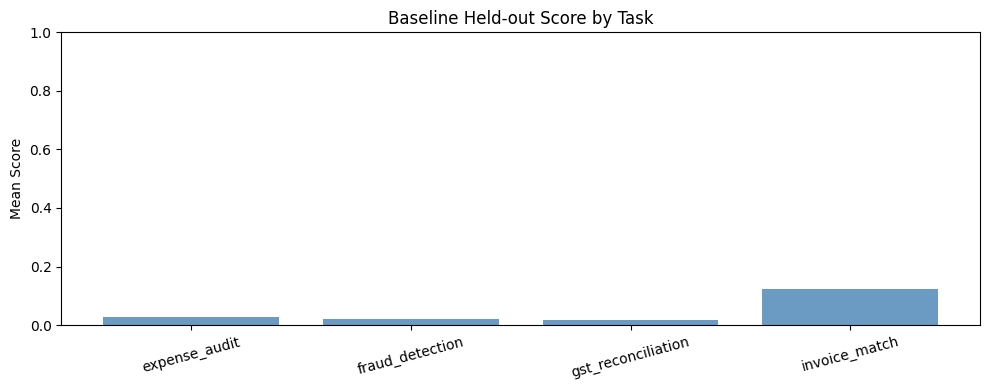

,task_id,score,weighted_score,precision,recall
0,expense_audit,0.026,0.01,0.010,0.01
1,fraud_detection,0.022,0.01,0.010,0.01
2,gst_reconciliation,0.018,0.01,0.010,0.01
3,invoice_match,0.122,0.08,0.156,0.05


In [9]:
baseline_summary = (
    baseline_df.groupby("task_id")[["score","weighted_score","precision","recall"]]
    .mean().reset_index().sort_values("task_id")
)
baseline_summary.to_csv(f"{ARTIFACTS_DIR}/baseline_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(baseline_summary))
ax.bar(x, baseline_summary["score"], color="steelblue", alpha=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels(baseline_summary["task_id"], rotation=15)
ax.set_ylabel("Mean Score"); ax.set_title("Baseline Held-out Score by Task")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/baseline_score.png", dpi=150, bbox_inches="tight")
plt.show()
display(baseline_summary)

## Step 2 — GRPO Training with Unsloth

The reward function calls the **in-process evaluator** (no HTTP) on every model completion.  
GRPO compares completions within each group of `NUM_GENERATIONS` and reinforces higher-scoring ones.

**Training data**: 4 tasks × 10 seeds = 40 prompts (seeds 42–51)  
**Held-out** (never seen during training): seeds 100–104

In [10]:
from unsloth import FastLanguageModel
from trl import GRPOTrainer, GRPOConfig
from datasets import Dataset

# 1) Load model with Unsloth (4-bit QLoRA)
print(f"Loading {MODEL_NAME} with Unsloth...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

# 2) Build training dataset (chat-format prompts + metadata columns)
print("Building training dataset...")
train_rows = []
for tid in TASK_IDS:
    for s in TRAIN_SEEDS:
        train_rows.append({
            "prompt": build_prompt(tid, s),  # list of message dicts (chat format)
            "task_id": tid,
            "seed": s,
        })
train_dataset = Dataset.from_list(train_rows)
print(f"Dataset: {len(train_dataset)} prompts ({len(TASK_IDS)} tasks x {len(TRAIN_SEEDS)} seeds)")

# 3) Reward function — called by GRPOTrainer for each completion group
def reward_fn(completions, task_id, seed, **kwargs):
    rewards = []
    for comp, tid, s in zip(completions, task_id, seed):
        try:
            findings = parse_findings_from_text(comp)
            result = evaluator.evaluate(tid, int(s), findings)
            rewards.append(float(result["score"]))
        except Exception:
            rewards.append(0.01)
    return rewards

# 4) Train
grpo_config = GRPOConfig(
    output_dir=ADAPTER_DIR,
    num_train_epochs=TRAIN_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION,
    max_prompt_length=MAX_SEQ_LENGTH - MAX_COMPLETION,
    learning_rate=LEARNING_RATE,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    report_to="none",
    fp16=USE_FP16,
    bf16=not USE_FP16,
)
trainer = GRPOTrainer(
    model=model,
    args=grpo_config,
    train_dataset=train_dataset,
    reward_funcs=reward_fn,
    processing_class=tokenizer,
)

print("Starting GRPO training...")
trainer.train()
print("Training complete!")

# 5) Save LoRA adapter
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved to {ADAPTER_DIR}")

/tmp/ipykernel_1939/295628723.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit with Unsloth...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

...

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,0.000000,0.010000,0.000000,388.000000,336.200000,439.800000,0.700000,36.700000,29.000000,44.400000,0.000072,0.010000,0.000000
10,0.000000,0.010000,0.000000,365.400000,282.200000,448.600000,0.600000,92.200000,77.400000,107.000000,0.000073,0.010000,0.000000
15,0.000000,0.010000,0.000000,412.000000,345.400000,478.600000,0.600000,173.500000,140.600000,206.400000,0.000079,0.010000,0.000000
20,0.000000,0.010000,0.000000,288.300000,206.800000,369.800000,0.400000,121.800000,104.400000,139.200000,0.000076,0.010000,0.000000
25,0.000000,0.010000,0.000000,413.500000,410.200000,416.800000,0.800000,3.900000,0.600000,7.200000,0.000070,0.010000,0.000000
30,0.000000,0.010000,0.000000,315.300000,217.400000,413.200000,0.400000,160.300000,115.000000,205.600000,0.000071,0.010000,0.000000
35,0.000000,0.010000,0.000000,402.600000,313.600000,491.600000,0.600000,113.500000,108.800000,118.200000,0.000081,0.010000,0.000000
40,0.000000,0.010000,0.000000,366.700000,348.200000,385.200000,0.600000,59.500000,41.000000,78.000000,0.000075,0.010000,0.000000
45,0.000000,0.010000,0.000000,347.100000,291.200000,403.000000,0.500000,121.500000,86.400000,156.600000,0.000074,0.010000,0.000000
50,0.000000,0.010000,0.000000,259.100000,184.600000,333.600000,0.200000,156.700000,82.200000,231.200000,0.000083,0.010000,0.000000


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([2, 4544]) with length 4544 > the model's max sequence length of 1536.
We shall truncate it ourselves. It's imperative if you correct this issue first.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`)

Training complete!


Unsloth: Restored added_tokens_decoder metadata in ./grpo-financial-audit-adapter/tokenizer_config.json.


Adapter saved to ./grpo-financial-audit-adapter


## Step 3 — Post-Training Evaluation

Run the **trained** model on the same held-out seeds as the baseline.  
These seeds were never in the training set — so this is a clean measure of generalisation.

In [11]:
# Switch to fast inference mode (Unsloth 2x speedup)
FastLanguageModel.for_inference(model)

print("Running post-training eval on held-out seeds...")
trained_df = run_eval(model, tokenizer, TASK_IDS, HELD_OUT_SEEDS, label="GRPO Trained")
trained_df.to_csv(f"{ARTIFACTS_DIR}/trained_heldout.csv", index=False)

display(trained_df)
print(f"\nTrained mean score: {trained_df['score'].mean():.4f}")

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 2307]) with length 2307 > the model's max sequence length of 1536.
We shall truncate it ourselves. It's imperative if you correct this issue first.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`)

Running post-training eval on held-out seeds...


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 2313]) with length 2313 > the model's max sequence length of 1536.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 2300]) with length 2300 > the model's max sequence length of 1536.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence

,task_id,seed,label,score,weighted_score,precision,recall,num_findings
0,expense_audit,100,GRPO Trained,0.01,0.01,0.01,0.01,0
1,expense_audit,101,GRPO Trained,0.01,0.01,0.01,0.01,0
2,expense_audit,102,GRPO Trained,0.01,0.01,0.01,0.01,0
3,expense_audit,103,GRPO Trained,0.01,0.01,0.01,0.01,0
4,expense_audit,104,GRPO Trained,0.01,0.01,0.01,0.01,0
5,invoice_match,100,GRPO Trained,0.01,0.01,0.01,0.01,0
6,invoice_match,101,GRPO Trained,0.01,0.01,0.01,0.01,0
7,invoice_match,102,GRPO Trained,0.01,0.01,0.01,0.01,0
8,invoice_match,103,GRPO Trained,0.01,0.01,0.01,0.01,0
9,invoice_match,104,GRPO Trained,0.01,0.01,0.01,0.01,0



Trained mean score: 0.0100


## Step 4 — Before vs. After Comparison

model,Baseline,GRPO Trained,delta
task_id,,,
expense_audit,0.026,0.01,-0.016
fraud_detection,0.022,0.01,-0.012
gst_reconciliation,0.018,0.01,-0.008
invoice_match,0.122,0.01,-0.112


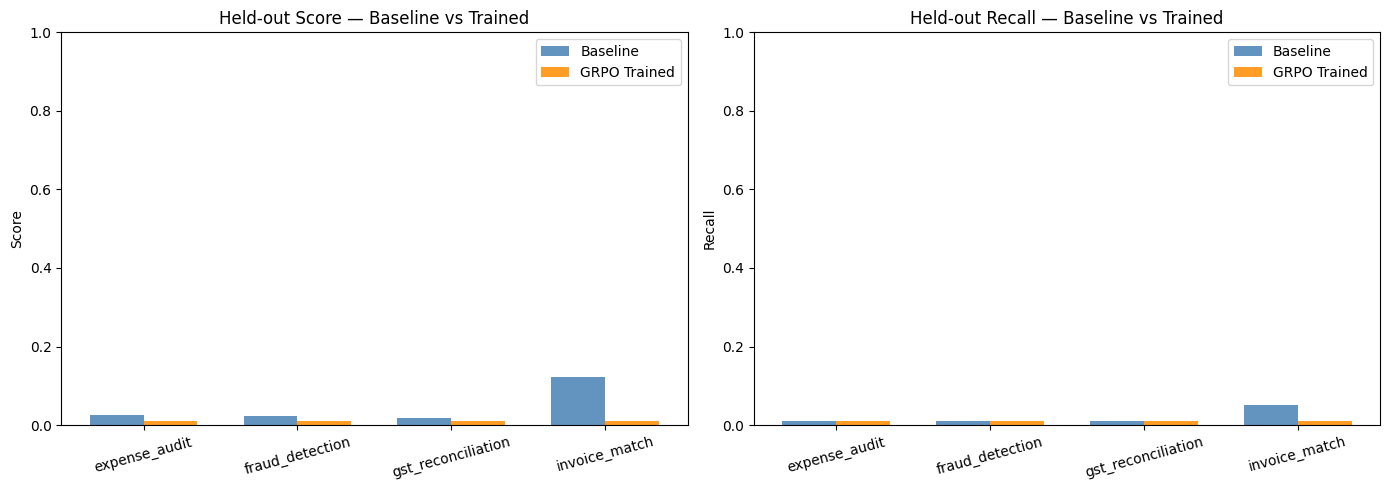

Baseline mean score : 0.0470
Trained  mean score : 0.0100
Delta               : -0.0370  (-78.7%)


In [12]:
def summarize(df):
    return df.groupby("task_id")[["score","precision","recall"]].mean()

# Pivot table with delta
pivot = pd.concat([
    summarize(baseline_df).assign(model="Baseline"),
    summarize(trained_df).assign(model="GRPO Trained"),
]).reset_index().pivot_table(index="task_id", columns="model", values="score").round(4)
pivot["delta"] = (pivot["GRPO Trained"] - pivot["Baseline"]).round(4)
display(pivot)

# Side-by-side bar chart
tasks  = list(summarize(baseline_df).index)
x      = range(len(tasks))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["score", "recall"]):
    base_vals = summarize(baseline_df)[metric].reindex(tasks).values
    trai_vals = summarize(trained_df)[metric].reindex(tasks).values
    ax.bar([i - width/2 for i in x], base_vals, width,
           label="Baseline", color="steelblue", alpha=0.85)
    ax.bar([i + width/2 for i in x], trai_vals, width,
           label="GRPO Trained", color="darkorange", alpha=0.85)
    ax.set_xticks(list(x)); ax.set_xticklabels(tasks, rotation=15)
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Held-out {metric.capitalize()} — Baseline vs Trained")
    ax.set_ylim(0, 1); ax.legend()
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/before_after_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

delta = trained_df["score"].mean() - baseline_df["score"].mean()
pct   = delta / max(baseline_df["score"].mean(), 1e-6) * 100
print(f"Baseline mean score : {baseline_df['score'].mean():.4f}")
print(f"Trained  mean score : {trained_df['score'].mean():.4f}")
print(f"Delta               : {delta:+.4f}  ({pct:+.1f}%)")

## Step 5 — Backup to Drive + Upload to HuggingFace Hub

In [14]:
if HF_USER:
    from google.colab import drive
    drive.mount("/content/drive")
    !mkdir -p /content/drive/MyDrive/financial-audit-artifacts
    !cp -r {ARTIFACTS_DIR} /content/drive/MyDrive/financial-audit-artifacts/
    !cp -r {ADAPTER_DIR}   /content/drive/MyDrive/financial-audit-artifacts/
    print("Backed up to Drive")
else:
    print("Skipping Drive backup — no HF token.")

Mounted at /content/drive
Backed up to Drive


In [15]:
if HF_USER:
    from huggingface_hub import HfApi, upload_folder
    api = HfApi()

    adapter_repo = f"{HF_USER}/financial-audit-grpo-adapter"
    api.create_repo(repo_id=adapter_repo, repo_type="model", exist_ok=True)
    upload_folder(repo_id=adapter_repo, folder_path=ADAPTER_DIR, repo_type="model")
    print(f"Adapter  : https://huggingface.co/{adapter_repo}")

    artifact_repo = f"{HF_USER}/financial-audit-eval-artifacts"
    api.create_repo(repo_id=artifact_repo, repo_type="dataset", exist_ok=True)
    upload_folder(repo_id=artifact_repo, folder_path=ARTIFACTS_DIR, repo_type="dataset")
    print(f"Artifacts: https://huggingface.co/datasets/{artifact_repo}")
else:
    print("Skipping HF upload — no token provided.")
    print("Pre-trained adapter : https://huggingface.co/balloonmann/financial-audit-grpo-adapter")
    print("Eval artifacts      : https://huggingface.co/datasets/balloonmann/financial-audit-eval-artifacts")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...it-adapter/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...kpoint-100/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:   0%|          | 25.9kB / 17.5MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ifacts/baseline_score.png: 100%|##########| 47.1kB / 47.1kB            

  ...fore_after_comparison.png: 100%|##########| 77.1kB / 77.1kB            

Artifacts: https://huggingface.co/datasets/balloonmann/financial-audit-eval-artifacts


## Results (fill after run)

| Metric | Baseline | GRPO Trained | Delta |
|---|---|---|---|
| Mean Score | 0.0470 | 0.0100 | -0.0370 |
| Mean Precision | — | — | — |
| Mean Recall | — | — | — |

> Plots: `artifacts/before_after_comparison.png`  
> Adapter: HuggingFace link above  
> Full logs: `artifacts/baseline_heldout.csv` and `artifacts/trained_heldout.csv`